# DAC26 ROSA: simulated EDP reproduction
This notebook consumes one completed `reproduce` run. It never reads the committed reference CSVs as experiment results and intentionally excludes accuracy/noise evaluation.

In [1]:
import json, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
run_dir = Path(os.environ['OPTICALLOOP_RUN_DIR']).resolve()
metadata = json.loads((run_dir / 'run.json').read_text())
artifacts = run_dir / 'artifacts'
raw = pd.read_csv(artifacts / 'layer_results.csv')
aggregates = pd.read_csv(artifacts / 'network_architecture_metrics.csv')
checks = pd.read_csv(artifacts / 'validation.csv')
headline = json.loads((artifacts / 'headline.json').read_text())
metadata['provenance'], metadata['tier'], metadata['successful_jobs'], metadata['expected_jobs']

({'accelergy': '0.4',
  'git_commit': '734c6d8c9a1aae5dc693007b7369b827d205883e',
  'git_dirty': False,
  'platform': 'Linux-5.15.0-176-generic-x86_64-with-glibc2.35',
  'python': '3.10.12',
  'timeloop_mapper': 'timeloop-mapper size=2035552 sha256=2ff90b894d3152e032d8fc4c0db3391c426aee28f004e2480bf70b8d111a3f33',
  'timeloopfe': '0.4'},
 'full',
 7040,
 7040)

## Coverage and simulator invariants

In [2]:
coverage = raw.groupby(['network', 'variant', 'architecture']).size().rename('simulated_layers').reset_index()
display(coverage)
display(checks)

,network,variant,architecture,simulated_layers
0,alexnet,no_osa,c4_r16,8
1,alexnet,no_osa,c4_r32,8
2,alexnet,no_osa,c4_r8,8
3,alexnet,no_osa,c8_r16,8
4,alexnet,no_osa,c8_r32,8
...,...,...,...,...
115,vision_transformer,osa,c8_r4,98
116,vision_transformer,osa,compact_4x4,98
117,vision_transformer,osa,deap_high_channel,98
118,vision_transformer,osa,deap_wide_kernel,98


,check,severity,status,detail
0,job_coverage,ERROR,PASS,7040/7040 successful jobs
1,no_duplicate_jobs,ERROR,PASS,7040 unique
2,edp_equals_energy_times_latency,ERROR,PASS,max relative error=0.000e+00
3,committed_reference_metrics,ERROR,FAIL,max relative error=17.108%; missing=0
4,feasible_winner,ERROR,PASS,paper_optimum_8x8
5,paper:optimized_vs_compact_reduction,WARNING,WARN,"actual=31.9075%, paper=26.0000%, delta=5.91%"
6,paper:optimized_vs_deap_reduction,WARNING,WARN,"actual=44.9246%, paper=64.0000%, delta=19.08%"
7,paper:osa_reduction,WARNING,WARN,"actual=22.9265%, paper=29.0000%, delta=6.07%"
8,paper:optimized_ode,WARNING,WARN,raw ODE configuration/data unavailable
9,paper:hybrid_edp,WARNING,WARN,paper table values are supplied without a comp...


## EDP reconstructed from simulated energy and latency

In [3]:
raw['recomputed_edp_j_s'] = raw.energy_j * raw.latency_s
assert ((raw.edp_j_s - raw.recomputed_edp_j_s).abs() <= raw.edp_j_s.abs().clip(lower=1e-30) * 1e-9).all()
display(aggregates)

,network,variant,architecture,tiles,pes,cols,rows,layers,energy_j,latency_s,edp_j_s
0,mobilenet_v3,osa,deap_wide_kernel,1,1,100,12,64,0.653756,0.179049,0.117054
1,vision_transformer,no_osa,c8_r4,1,32,8,4,98,57.100361,1.685705,96.254383
2,mobilenet_v3,osa,c4_r32,1,8,4,32,64,0.760669,0.153327,0.116631
3,gpt2_medium,osa,c8_r16,1,8,8,16,145,178.957032,9.051937,1619.907811
4,vision_transformer,osa,c4_r16,1,16,4,16,98,41.314535,1.685780,69.647203
...,...,...,...,...,...,...,...,...,...,...,...
115,vgg16,osa,c8_r16,1,8,8,16,16,39.453459,2.740657,108.128380
116,alexnet,no_osa,c8_r32,1,4,8,32,8,2.810567,0.138593,0.389524
117,alexnet,osa,c8_r4,1,32,8,4,8,2.415726,0.123190,0.297592
118,alexnet,osa,deap_wide_kernel,1,1,100,12,8,1.197202,0.067738,0.081096


## Full-sweep architecture and OSA comparison
Headline metrics are available only for the full tier. Paper deltas remain visible where the publication omits λ or raw ODE inputs.

{'available': True,
 'winner': 'paper_optimum_8x8',
 'optimized_vs_compact_reduction': 0.3190754326696389,
 'optimized_vs_deap_reduction': 0.4492457425164815,
 'osa_reduction': 0.22926520230030834}

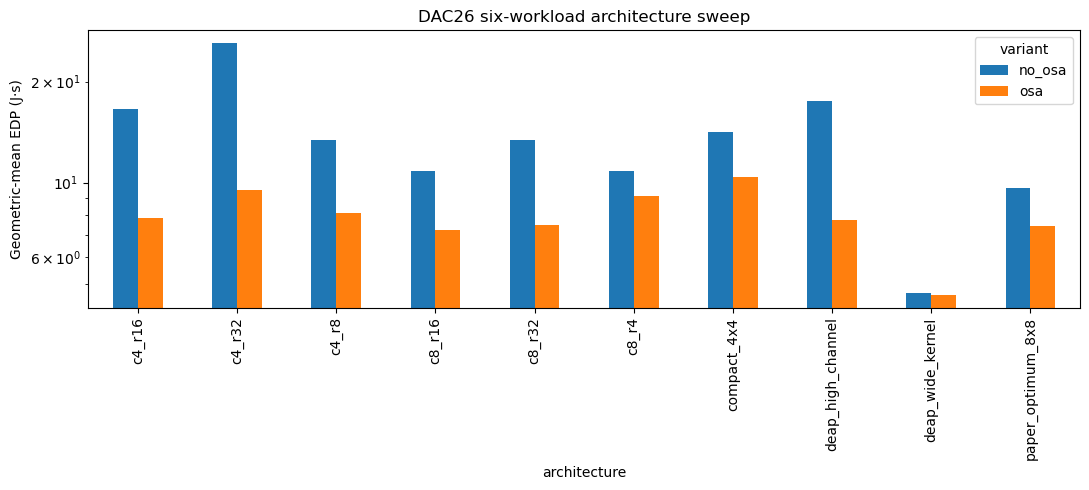

In [4]:
display(headline)
if headline.get('available'):
    chart = aggregates.groupby(['architecture', 'variant']).edp_j_s.apply(lambda s: (s.prod()) ** (1 / len(s))).unstack()
    ax = chart.plot.bar(figsize=(11, 5), logy=True, ylabel='Geometric-mean EDP (J·s)')
    ax.set_title('DAC26 six-workload architecture sweep')
    plt.tight_layout()
    plt.savefig(artifacts / 'architecture_edp.png', dpi=160)
    plt.show()

## Conclusion
The authoritative result is `artifacts/REPORT.md`. `PASS_WITH_PAPER_GAPS` means all simulated invariants and reference checks pass while one or more publication-only claims cannot be independently reconstructed from disclosed inputs.